In [208]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [209]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [210]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix
R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
Vinc = E0*np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector
Zmat = Zs * Lmat # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = -np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj) + obj0 # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  207
Objective for full plate: 7.046531e+00 W


In [211]:
# # use Schur complemet to satisfy given iBFfixed row of system equation Ztot @ Ivec = Vinc
# iBFfixed = 261
# # Split the total impedance matrix into blocks for iBFfixed and the remaining variables
# Z11 = Ztot[iBFfixed, iBFfixed] # scalar
# Z12 = Ztot[iBFfixed, np.arange(Ndes) != iBFfixed] # row vector
# Z21 = Ztot[np.arange(Ndes) != iBFfixed, iBFfixed] # column vector
# Z22 = Ztot[np.ix_(np.arange(Ndes) != iBFfixed, np.arange(Ndes) != iBFfixed)] # matrix
# Vinc1 = Vinc[iBFfixed] # scalar
# Vinc2 = Vinc[np.arange(Ndes) != iBFfixed] # vector

# # Compse reduction to variables excluding iBFfixed
# # Ivec = Tmat @ Ivec2 + Ivec1

# # Tmat is identity with -np.linalg.solve(Z11, Z12) in the iBFfixed row
# Tmat = np.zeros((Ndes, Ndes-1), dtype=complex)
# Tmat[np.arange(Ndes) != iBFfixed, :] = np.eye(Ndes-1)
# Tmat[iBFfixed, :] = -Z12/Z11

# # Ivec1 is zero except for the iBFfixed row, which is np.linalg.solve(Z11, Vinc1)
# Ivec1 = np.zeros(Ndes, dtype=complex)
# Ivec1[iBFfixed] = Vinc1/Z11

# # reduced operators
# Lmatr = Lmat[np.ix_(np.arange(Ndes) != iBFfixed, np.arange(Ndes) != iBFfixed)]
# Ztotr = Z22 - np.outer(Z21, Z12 / Z11)
# Vincr = Vinc2 - Z21 * (Vinc1/Z11)

# # transformed objectives
# Objr = Tmat.conj().T @ Obj @ Tmat
# objr = 2 * Tmat.conj().T @ Obj @ Ivec1 + Tmat.conj().T @ obj
# obj0r = Ivec1.conj().T @ Obj @ Ivec1 + np.real(Ivec1.conj().T @ obj) + obj0

# # verify scattered value of the full plate
# Ivec2 = np.linalg.solve(Ztotr, Vincr)
# Ivec_full = Tmat @ Ivec2 + Ivec1
# Obj_full = np.real(Ivec_full.conj().T @ Obj @ Ivec_full) + np.real(Ivec_full.conj().T @ obj) + obj0
# print(f"Full plate objective: {Obj_full}")

# # Cholesky
# Lchol = np.linalg.cholesky(Lmatr).conj().T
# Mfactor = np.linalg.inv(Lchol)
# Vincf = Mfactor.conj().T @ Vincr
# Ztotf = Mfactor.conj().T @ Ztotr @ Mfactor
# Objf = Mfactor.conj().T @ Objr @ Mfactor
# objf = Mfactor.conj().T @ objr
# obj0f = obj0r

# Ivec2f = np.linalg.solve(Ztotf, Vincf)
# Objf_full = np.real(Ivec2f.conj().T @ Objf @ Ivec2f) + np.real(Ivec2f.conj().T @ objf) + obj0f
# print(f"Full plate objective after transformation: {Objf_full}")




In [212]:
# Assuming Ndes is OP.BF.nUnknowns and is an odd integer
k = (Ndes - 1) // 2

# 1. Upper block: Identity matrix of size (k + 1)
upper = np.eye(k + 1)

# 2. Lower block: Flipped identity of size k, followed by a column of zeros
# np.fliplr(np.eye(k)) creates the anti-diagonal matrix
lower_left = np.fliplr(np.eye(k))
lower_right = np.zeros((k, 1))
lower = np.hstack([lower_left, lower_right])

# 3. Vertically stack them to create C
C = np.vstack([upper, lower])

# lossy matrix Cholesky factorization
Lchol = np.linalg.cholesky(C.conj().T @Lmat @ C).conj().T

Mfactor = C @ np.linalg.inv(Lchol)
# Mfactor = np.eye(Ndes) # skip transformation for testing purposes
# Mfactor = C

Vincf = Mfactor.conj().T @ Vinc
Ztotf = Mfactor.conj().T @ Ztot @ Mfactor
Z0f = Mfactor.conj().T @ Z0 @ Mfactor
Zmatf = Mfactor.conj().T @ Zmat @ Mfactor
Objf = Mfactor.conj().T @ Obj @ Mfactor
objf = Mfactor.conj().T @ obj
obj0f = obj0

Nfac = Z0f.shape[0]
iVec = np.zeros(Nfac, dtype=complex) # particular solution to satisfy the fixed current constraint (zero for now, can be used to satisfy a fixed current constraint by setting the iBFfixed row to np.linalg.solve(Z11, Vinc1) and the transformation matrix to have -np.linalg.solve(Z11, Z12) in the iBFfixed row)

In [213]:
# translate QCQP matrices to Dolphindes notation
Umat = 1j * Ztotf.conj() # Dolphindes U matrix
eVec = -1j*Vincf.conj() / 2 # Dolphindes e vector
Bmat = Objf # quadratic objective matrix
bVec = objf # linear objective vector
beta = obj0f # constant objective term

In [ ]:
# # preconditioner for projection constraints
# G0 = Z0f # Green's function matrix
# D = np.diag(np.diag(Z0f)) # Green's matrix diagonal
# X = np.linalg.inv(Zmatf) # material admittance matrix
# H0 = G0 - D
# Y = np.linalg.solve(np.eye(Nfac) + X @ D, X)
# iVec = X @ Vincf

# S = np.eye(Nfac) + Y @ H0 # preconditioner matrix for projection constraints
# q = -Y @ G0 @ iVec

# P0 = np.linalg.solve(S, Ztotf)

# sVec = np.linalg.solve(S, q)
# tVec = sVec + iVec
# Vtest = Ztotf @ tVec
# print(f"voltage error: {np.max(np.abs(Vtest - Vincf))/np.max(np.abs(Vincf)):.2e}")

# print(f"asymmetric error of preconditioner: {np.linalg.norm(S-S.T, ord='fro')/np.linalg.norm(S, ord='fro'):.2e}")
# S = (S + S.T) / 2

# Ptr0 = -np.real(tVec.conj().T @ Objf @ tVec) + 2*np.real(tVec.conj().T @ objf) + obj0f
# print(f"power error without shifting preconditioner: {np.abs(Ptr0 - Pfull)/np.abs(Pfull):.2e}")

# obj0f += -np.real(iVec.conj().T  @ Objf @ iVec) + 2*np.real(iVec.conj().T @ objf)
# objf += -Objf @ iVec

# Ptr = -np.real(sVec.conj().T @ Objf @ sVec) + 2*np.real(sVec.conj().T @ objf) + obj0f
# print(f"power error with preconditioner: {np.abs(Ptr - Pfull)/np.abs(Pfull):.2e}")

# Umat = 1j * S
# eVec = -1j*q / 2
# Bmat = Objf
# bVec = objf
# beta = obj0f

In [215]:
# set up optimization variables
Nopt = Umat.shape[0] # number of optimization variables (after reduction)

# 1. Use np.column_stack to create a proper 2D NumPy array
# 2. Use np.ones(Nopt) instead of np.ones((Nopt,1))
# Pdiags = np.column_stack([
#     -1j * np.ones((Nopt,1), dtype=complex), 
#     np.eye(Nopt, dtype=complex)
# ])
Pdiags = np.column_stack([
    -1j *np.eye(Nopt, dtype=complex), 
    np.eye(Nopt, dtype=complex)
])

# Now Pdiags is a NumPy array, so .shape and [:,i] will work perfectly
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec,
                             Plist, verbose = 1
                                )


t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
# lags_init[0] = 1
lags_init[0:Nopt] = 1
# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-15,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=30,                
    penalty_ratio=1e-3,           
    penalty_reduction=0.01,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 208 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 1e-15
gradConverge: True
min_inner_iter: 10
max_restart: 30
penalty_ratio: 0.001
penalty_reduction: 0.01
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Outer iteration 0, penalty_ratio = 0.001, opt_fx = 12.76959893252199
iter_num: 5, prev_fx: inf, opt_fx: 12.

In [216]:
# # set up optimization variables
# Nopt = Umat.shape[0] # number of optimization variables (after reduction)

# Pdiags = np.ones((Nopt,2), dtype=complex) # gloal constraints
# Pdiags[:,1] = -1j
# # norm_list = [np.linalg.norm(np.imag(Ztotf)), np.linalg.norm(np.real(Ztotf))]
# norm_list = [1, 1]
# Plist = [sp.diags(Pdiags[:,i] / norm_list[i]) for i in range(Pdiags.shape[1])]

# # # Set up and solve QCQP
# # Pdiags = 'global' # use global constraints

# QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
#                             Umat, eVec,
#                              Plist, verbose = 1
#                                 )

# # print(f"norm eVec: {np.linalg.norm(eVec)}")

# # iBFfixed = 261

# # B_j = [np.zeros((Ndes, Ndes), dtype=complex),
# #        np.zeros((Ndes, Ndes), dtype=complex)]
# # s_2j = [(Ztot[iBFfixed,:] @ Mfactor).conj()/2,
# #         1j*(Ztot[iBFfixed,:] @ Mfactor).conj()/2]
# # c_2j = [-np.real(Vinc[iBFfixed].conj()),
# #         np.imag(Vinc[iBFfixed].conj())]   # constant term for that constraint

# # QCQP = DenseSharedProjQCQP(
# #     Bmat, bVec, beta,
# #     Umat, eVec,
# #     Plist,
# #     A2=np.eye(Ndes, dtype=complex),
# #     B_j=B_j,
# #     s_2j=s_2j,
# #     c_2j=c_2j,
# #     verbose=1,
# # )

# t1 = time.time()
# # lags_init = np.zeros((Pdiags.shape[1]+len(B_j),))
# lags_init = np.zeros((Pdiags.shape[1],))
# lags_init[1] = 1e4
# # lags_init = np.array([-5.14829512e-04, 8.95749133e-01]) # initial guess for Lagrange multipliers, can be set to zero or some other value. Here we use the optimal values from the previous BFGS optimization for faster convergence.
# # lags_init = np.array([-53.92809642, 9.3006329 ])

# # New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
# opt_params = OptimizationHyperparameters(opttol=1e-4,                  
#     gradConverge=True,           
#     min_inner_iter=10,             
#     max_restart=10,                
#     penalty_ratio=1e-2,           
#     penalty_reduction=0.1,        
#     break_iter_period=5,          
#     verbose=1)

# # Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
# result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
# print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

In [217]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 

Pdiags = QCQP.Proj.Pdiags
iChol = QCQP.current_xstar


constraintVal = iChol.conj().T @ np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Umat @ iChol - 2 * eVec)

print(f"constraint value: {constraintVal}")


Ivec = Mfactor @ (iChol + iVec) # optimal current distribution in original coordinates
Popt = np.real(Ivec.conj().T @ Obj @ Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.2e} W")

constraintVal = Ivec.conj().T @ (Ztot @ Ivec - Vinc)
print(f"constraint value in original coordinates: {constraintVal}")

# save optimal current complex vector as a real-imag text file
Ivec_realimag = np.zeros((Ndes,2))  # create a new array with two columns
Ivec_realimag[:,0] = np.real(Ivec)  # first column is the real part
Ivec_realimag[:,1] = np.imag(Ivec)  # second column is the imaginary part
np.savetxt("Ivec_optimal_realimag.txt", Ivec_realimag, delimiter=',')

minimum eigenvalue: 3.357422601808003e-10
constraint value: (40.98582433822624-12.939759246160271j)
Optimal objective value: -1.02e+01 W
constraint value in original coordinates: (-3.483299435773357e-05+12.996465866988675j)


In [218]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=False,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-12,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=10,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=0,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=10,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=False,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

At GCD iteration #1, best dual bound found is             10.246571090765093.
gcd optimization took time 8.766085147857666.


In [219]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 0.000577487797849549


bound: 10.246570027746841, time: 3.0639095306396484s
min eigenvalue: 1.9738160248192143e-05


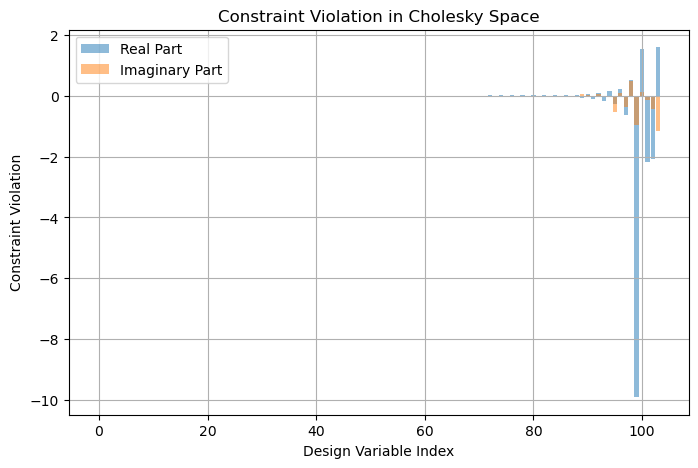

GCD primary objective: -10.246581230826553
GCD dual bound: 10.246570027746841
Objective with GCD solution: -10.246581230826553
constraint value: (40.98584929122532-12.963381721966366j)
Lagrange multipliers: [ 9.89889207e-01  9.89893579e-01  9.89897592e-01  9.89901311e-01
  9.89904876e-01  9.89908275e-01  9.89911534e-01  9.89914655e-01
  9.89917652e-01  9.89920527e-01  9.89923288e-01  9.89925939e-01
  9.89928485e-01  9.89930930e-01  9.89933278e-01  9.89935533e-01
  9.89937698e-01  9.89939776e-01  9.89941771e-01  9.89943685e-01
  9.89945522e-01  9.89947284e-01  9.89948974e-01  9.89950593e-01
  9.89952146e-01  9.89953634e-01  9.89955059e-01  9.89956423e-01
  9.89957729e-01  9.89958979e-01  9.89960175e-01  9.89961317e-01
  9.89962410e-01  9.89963453e-01  9.89964450e-01  9.89965401e-01
  9.89966309e-01  9.89967174e-01  9.89967999e-01  9.89968784e-01
  9.89969532e-01  9.89970244e-01  9.89970920e-01  9.89971563e-01
  9.89972174e-01  9.89972754e-01  9.89973304e-01  9.89973825e-01
  9.89974318e

In [220]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
Pdiags = gcd_QCQP.Proj.Pdiags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

iChol = gcd_QCQP.current_xstar
qLocal= iChol.conj() * (Umat.conj().T @ iChol)
lLocal = 2 * iChol.conj() * eVec
con_violation = 1j*((lLocal - qLocal) / np.abs(0.5*(lLocal + qLocal))).conj() # constraint violation normalized by the magnitude of the constraint value, to get a relative measure of violation. This is more informative than normalizing by lLocal alone, since qLocal can be large and make the violation seem small when it's actually significant.
# plot bar real and imag parts of constraint violation
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Nopt), np.real(con_violation), alpha=0.5, label='Real Part')
plt.bar(np.arange(Nopt), np.imag(con_violation), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('Constraint Violation')
plt.title('Constraint Violation in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


primar_obj = np.real(iChol.conj().T @ Bmat @ iChol + bVec.conj().T @ iChol + beta)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

Ivec = Mfactor @ (iChol + iVec)
Porg = np.real(Ivec.conj().T @ Obj @ Ivec)
print(f"Objective with GCD solution: {Porg}")

constraintVal = iChol.conj().T @ np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Umat @ iChol - 2 * eVec)
print(f"constraint value: {constraintVal}")

# print lags
print(f"Lagrange multipliers: {lags}")

# save optimal current complex vector as a real-imag text file
Ivec_realimag = np.zeros((Ndes,2))  # create a new array with two columns
Ivec_realimag[:,0] = np.real(Ivec)  # first column is the real part
Ivec_realimag[:,1] = np.imag(Ivec)  # second column is the imaginary part
np.savetxt("Ivec_optimalGCD_realimag.txt", Ivec_realimag, delimiter=',')

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
inference error: 1.9420999197544493


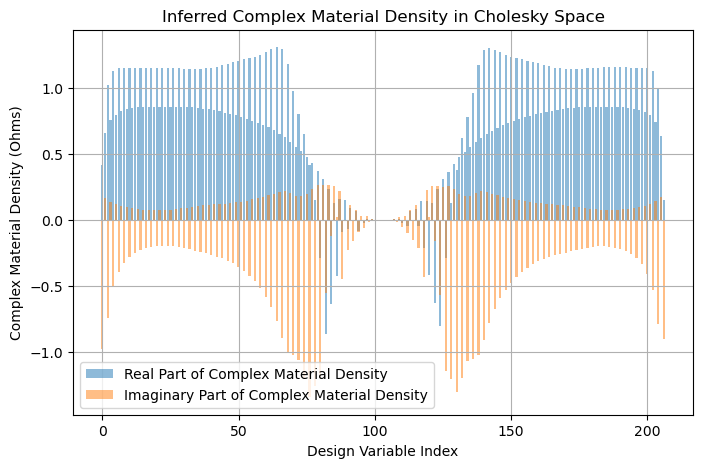

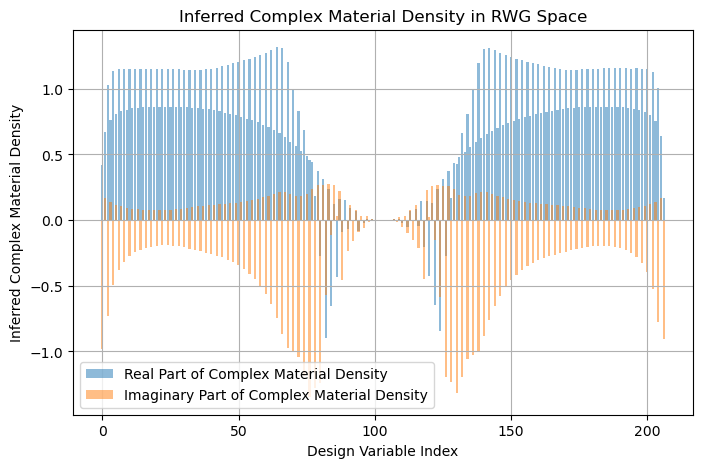

Objective for inferred material density: -1.024658e+01 W


In [221]:
# infer conductivity
Lchol = np.linalg.cholesky(Lmat).conj().T
MfactorInf = np.linalg.inv(Lchol)

# Ivec = np.linalg.solve(Ztot, Vinc) # optimal current distribution in original coordinates

iChol = Lchol @ Ivec
Z0fInf = MfactorInf.conj().T @ Z0 @ MfactorInf
VincfInf = MfactorInf.conj().T @ Vinc

Vopt = Z0fInf @ iChol
Vinf = VincfInf - Vopt
Zinff = Vinf / iChol

# Umd = 1j * np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Zmatf - np.diag(Zinff)).conj()
# Umds = Umd + Umd.conj().T
# eq4 = (iChol.conj().T @ Umds @ iChol)/(iChol.conj().T @ Zmatf @ iChol)
# print(f"eq4 value normalized by squared norm: {eq4}, expected to be close to zero for consistency with GCD solution")


print(f"Surface impedance: {Zs} Ω")

complexMaterialDensityChol = Zs / Zinff
print(f"inference error: {np.max(np.abs(complexMaterialDensityChol - 1))}")

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensityChol), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensityChol), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
diagZinf = np.diag(Zinf)
diagZmat = np.diag(Zmat)


complexMaterialDensity = diagZmat / diagZinf

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Inferred Complex Material Density')
plt.title('Inferred Complex Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

# evaluate performmance for inferred material density
ZtotInf = Z0 + Zinf
IfullInf = np.linalg.solve(ZtotInf, Vinc) # current distribution for inferred material density
PfullInf = np.real(IfullInf.conj().T @ Obj @ IfullInf) # radiated power for inferred material density
print(f"Objective for inferred material density: {PfullInf:.6e} W")


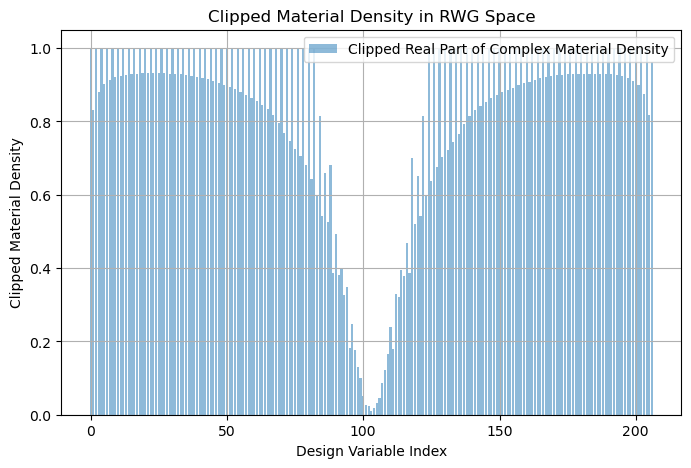

Objective for limited inferred material density: -8.0272e-01 W


In [222]:
# limit material density to be postive real [0,1]
material_density = np.sqrt(np.clip(np.abs(complexMaterialDensity), 1e-9, 1))
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

addLoss = 1/material_density
ZmatInfLim = np.diag(addLoss) @ Zmat @ np.diag(addLoss)
ZtotInfLim = Z0 + ZmatInfLim
IfullInfLim = np.linalg.solve(ZtotInfLim, Vinc) # current distribution for inferred material density
PfullInfLim = np.real(IfullInfLim.conj().T @ Obj @ IfullInfLim) # radiated power for inferred material density
print(f"Objective for limited inferred material density: {PfullInfLim:.4e} W")

np.savetxt("limited_material_density.txt", material_density, delimiter=',')

In [223]:
# import matplotlib.pyplot as plt

# # 1. Define the range of factors to sweep
# mRed = 15 # number of decades to reduce conductivity by
# factors = np.logspace(0, -mRed, 15*4+1)
# min_eigenvalues = []
# dual_bounds = []
# primary_objectives = []
# primary_original = []
# fullPlate_objectives = []
# inferred_objectives = []

# # Constants assumed from previous cells:
# # omega, epsilon_0, c, Lmat, R0, X0, Vinc, Bmat, bVec, beta, eVec, Vzero, Pdiags, X0Norm

# print(f"Starting sweep over {len(factors)} points...")

# for i, factor in enumerate(factors):
#     # --- A. Update Physics based on Factor ---
#     copper_conductivity = factor * 5.96e7 # Adjusted conductivity
    
#     # Recalculate Surface Impedance (Zs)
#     delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
#     Zs = (1 + 1j) / (copper_conductivity * delta)

#     Zmat = Zs * Lmat # updated resistance matrix
#     Rmat = np.real(Zmat) # updated resistance matrix

#     Zmatf = Mfactor.conj().T @ Zmat @ Mfactor  # updated material impedance matrix

#     Obj = -0.5 * R0
#     Objf = Mfactor.conj().T @ Obj @ Mfactor
#     objf = Mfactor.conj().T @ obj
#     obj0f = obj0
    

#     Ztotf = Z0f + Zmatf # total impedance matrix
    
#     Ifull = np.linalg.solve(Ztotf, Vincf) # current distribution for full plate with updated conductivity
#     Pfull = np.real(Ifull.conj().T @ Objf @ Ifull) # radiated power for full plate with updated conductivity
#     fullPlate_objectives.append(Pfull)

#     Umat = 1j * Ztotf.conj() # Dolphindes U matrix
#     eVec = -1j*Vincf.conj() / 2 # Dolphindes e vector
#     Bmat = Objf # quadratic objective matrix
#     bVec = objf # linear objective vector
#     beta = obj0f # constant objective term 
 
    
#     Pdiags = np.ones((Nopt,2), dtype=complex) # gloal constraints
#     Pdiags[:,1] = -1j
#     # norm_list = [np.linalg.norm(np.imag(Ztotf)), np.linalg.norm(np.real(Ztotf))]
#     norm_list = [1, 1]
#     Plist = [sp.diags(Pdiags[:, k] / norm_list[k]) for k in range(Pdiags.shape[1])]

#     # --- C. Setup QCQP ---
#     # We create a new QCQP instance for this specific conductivity
#     # verbose=0 to keep the output clean during the loop
#     gcdIter_QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
#                                Umat, eVec,
#                                Plist, verbose=0)

#     # --- D. Run GCD ---
#     gcd_tol = 1e-9
#     gcd_params = GCDHyperparameters(gcd_tol=gcd_tol)
    
#     # Run the solver
#     gcdIter_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)

#     gcdIter_QCQP.run_gcd(gcd_params=gcd_params)

#     gcdIter_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcdIter_QCQP.current_lags, opt_params = None)
    
#     # --- E. Calculate Minimal Eigenvalue ---
#     lags = gcdIter_QCQP.current_lags
#     totalA = gcdIter_QCQP._get_total_A(lags)
    
#     # Calculate eigenvalues
#     # Note: Using eigvalsh usually assumes Hermitian, which is generally true for the dual matrix
#     # but we stick to np.linalg.eig as per your notebook for safety
#     eigenvals, _ = np.linalg.eig(totalA)

#     iChol = gcdIter_QCQP.current_xstar
#     primar_obj = np.real(iChol.conj().T @ Bmat @ iChol + bVec.conj().T @ iChol + beta)
#     Ivec = Mfactor @ iChol
#     Porg = np.real(Ivec.conj().T @ Obj @ Ivec)
    
#     # We take the real part of the minimum eigenvalue
#     min_eig = np.min(np.real(eigenvals))
#     min_eigenvalues.append(min_eig)
#     dual_bounds.append(gcdIter_QCQP.current_dual)
#     primary_objectives.append(primar_obj)
#     primary_original.append(Porg)
    
#     iChol = Lchol @ Ivec
#     Z0fInf = MfactorInf.conj().T @ Z0 @ MfactorInf
#     VincfInf = MfactorInf.conj().T @ Vinc

#     Vopt = Z0fInf @ iChol
#     Vinf = VincfInf - Vopt
#     Zinff = Vinf / iChol
    
#     Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
#     diagZinf = np.diag(Zinf)
#     diagZmat = np.diag(Zmat)


#     complexMaterialDensity = diagZmat / diagZinf
    
#     material_density = np.sqrt(np.clip(np.abs(complexMaterialDensity), 1e-9, 1))
#     addLoss = 1/material_density
#     ZmatInfLim = np.diag(addLoss) @ Zmat @ np.diag(addLoss)
#     ZtotInfLim = Z0 + ZmatInfLim
#     IfullInfLim = np.linalg.solve(ZtotInfLim, Vinc) # current distribution for inferred material density
#     PfullInfLim = np.real(IfullInfLim.conj().T @ Obj @ IfullInfLim) # radiated power for inferred material density    
#     inferred_objectives.append(PfullInfLim)

#     print(f"Iter {i+1}/{len(factors)}: Factor={factor:.2e}, Min Eig={min_eig:.2e}, Objective={Porg:.2e}")


In [224]:
# plt.figure(figsize=(10, 6))
# plt.loglog(factors, min_eigenvalues, 'b-o', linewidth=2)
# plt.grid(True, which="both", ls="-")
# plt.xlabel('Conductivity Reduction Factor "s"')
# plt.ylabel('Min Eigenvalue')
# plt.title('GCD Minimal Eigenvalue vs Conductivity Reduction')
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.loglog(factors, np.abs(dual_bounds), 'r-o', linewidth=2)
# # plt.loglog(factors, np.abs(primary_objectives), 'g--+', linewidth=2)
# # plt.loglog(factors, np.abs(primary_original), 'k-.x', linewidth=2)
# plt.loglog(factors, np.abs(fullPlate_objectives), 'g--+', linewidth=2)
# plt.loglog(factors, np.abs(inferred_objectives), 'k-.x', linewidth=2)
# plt.grid(True, which="both", ls="-")
# plt.xlabel('Conductivity Reduction Factor "s"')
# plt.ylabel('Objective Values')
# plt.title('GCD Dual and Primary Objectives vs Conductivity Reduction')
# plt.legend(['Dual Bound', 'Full Plate', 'Clipped Inferred'], loc='best')
# plt.show()

# # plot relative performance with respect to dual bound
# plt.figure(figsize=(10, 6))
# plt.loglog(factors,  np.abs(fullPlate_objectives) / np.abs(dual_bounds), 'g--+', linewidth=2)
# plt.loglog(factors,  np.abs(inferred_objectives) / np.abs(dual_bounds), 'k-.x', linewidth=2)
# plt.grid(True, which="both", ls="-")
# plt.xlabel('Conductivity Reduction Factor "s"')
# plt.ylabel('Performance Relative to Dual Bound')
# plt.title('Relative Performance vs Conductivity Reduction')
# plt.legend(['Full Plate', 'Clipped Inferred'], loc='best')
# plt.show()